# Project 3: Acme Solving Informatin Overload with AI Powered Dialogue Summarization

## Project Overview

Modern organizations generate massive amounts of conversational data through customer support chats, messaging platforms, and internal communications. Manually reviewing and summarizing these conversations is time-consuming, costly, and prone to inconsistency.

This project develops an **end-to-end machine learning solution for automatic text summarization** using **transformer-based large language models (LLMs)**. Specifically, we fine-tune a pretrained **encoder–decoder transformer model (BART)** on the **SAMSum dataset**, which consists of real-world chat conversations paired with human-written summaries.

The goal of this system is to **condense multi-turn dialogues into concise, informative summaries** while preserving the key facts and intent of the conversation.


## Business Problem

Organizations need fast and accurate ways to:
- Summarize customer conversations
- Reduce manual review effort
- Improve decision-making based on communication logs

An automated summarization system can:
- Save time and operational costs
- Improve consistency across summaries
- Enable scalable analysis of conversational data



## Technical Objectives

This project aims to:
- Process and prepare conversational text data for deep learning
- Fine-tune a transformer-based encoder–decoder architecture
- Train the model efficiently under limited hardware constraints
- Evaluate performance using quantitative metrics (ROUGE)
- Analyze model outputs to identify strengths and limitations



## Deliverables

- A fully executable Jupyter Notebook with:
  - Data preprocessing
  - Model fine-tuning
  - Evaluation and visualization
  - Sample generated summaries
- Saved model weights for reuse
- Clear documentation explaining design decisions, challenges, and results


## Step 1. Environment Setup and Dependencies

This project uses the Hugging Face ecosystem for building and training transformer-based models. The following libraries are required:

- **datasets**: for loading and processing the SAMSum dataset
- **transformers**: for pretrained transformer models and training utilities
- **torch**: for deep learning computation
- **evaluate**: for computing ROUGE metrics
- **matplotlib / seaborn**: for visualization



In [4]:
# Core libraries
import os
import numpy as np
import pandas as pd

# Deep learning
import torch

# Hugging Face libraries
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer
)

# Evaluation
import evaluate

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns





## Step 2. Data Description

The SAMSum dataset is a collection of short chat conversations along with
human-written summaries. Each example consists of:

- A multi-turn dialogue between two or more speakers
- A concise reference summary written by a human annotator

The dataset is commonly used for benchmarking conversational summarization
models and is well-suited for transformer-based sequence-to-sequence approaches.
Conversational text differs from traditional documents because it includes:

- Multiple speakers
- Informal language and abbreviations
- Implicit references and context
- Short, fragmented utterances

These characteristics make the SAMSum dataset a strong test case for evaluating
the capabilities of transformer-based summarization models.

In [5]:
# Path to local dataset directory
data_dir = r"C:\Users\bhern\OneDrive\Desktop\Project 3 Large Language Model"

# Load dataset from CSV files
dataset = load_dataset(
    "csv",
    data_files={
        "train": f"{data_dir}\\train.csv",
        "validation": f"{data_dir}\\validation.csv",
        "test": f"{data_dir}\\test.csv",
    }
)

dataset

# Display dataset split sizes
for split in dataset:
    print(f"{split}: {len(dataset[split])} examples")


# View one training example
dataset["train"][0]



train: 14731 examples
validation: 818 examples
test: 819 examples


{'id': '13818513',
 'dialogue': "Amanda: I baked  cookies. Do you want some?\nJerry: Sure!\nAmanda: I'll bring you tomorrow :-)",
 'summary': 'Amanda baked cookies and will bring Jerry some tomorrow.'}

## Step 3. Tokenization and Preprocessing

Transformer models do not operate directly on raw text. Instead, text must be
converted into numerical representations called *tokens*.

Tokenization involves:
- Splitting text into subword units
- Mapping each token to a numerical ID
- Creating attention masks to distinguish real tokens from padding

In this project, tokenization is applied to both:
- The dialogue text (model input)
- The summary text (model target output)

## Tokenization Strategy

To ensure efficient training and stable memory usage, the following limits are used:

- Maximum input length: 512 tokens (dialogue text)
- Maximum target length: 128 tokens (summary text)

Longer sequences are truncated, and shorter ones are padded.
These values balance performance with computational efficiency.


In [6]:
from transformers import AutoTokenizer

model_checkpoint = "facebook/bart-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    # Tokenize the dialogue (model input)
    model_inputs = tokenizer(
        examples["dialogue"],
        max_length=512,
        truncation=True,
        padding="max_length"
    )

    # Tokenize the summary (model target)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples["summary"],
            max_length=128,
            truncation=True,
            padding="max_length"
        )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)


## Step 4. Model Architecture Selection

This project uses **BART (Bidirectional and Auto-Regressive Transformers)** as the
core model architecture.

BART is an encoder–decoder transformer model that is well-suited for text
summarization tasks because:

- The encoder processes the full dialogue context bidirectionally
- The decoder generates concise summaries autoregressively
- It has been pre-trained on large-scale text denoising tasks
- It performs strongly on conversational summarization benchmarks

The **facebook/bart-base** variant is chosen to balance:
- Model performance
- Training time
- Hardware constraints (CPU / limited GPU)



In [7]:
from transformers import AutoModelForSeq2SeqLM

model_checkpoint = "facebook/bart-base"
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

model


BartForConditionalGeneration(
  (model): BartModel(
    (shared): Embedding(50265, 768, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 768, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 768)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartSdpaAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_norm): Laye

## Step 5. Training Configuration Overview

Training large transformer models requires careful configuration to balance:

- Training time
- Memory usage
- Model performance
- Hardware limitations

In this project, training is performed using Hugging Face's `Trainer` API,
which abstracts much of the low-level training logic while allowing
fine-grained control through `TrainingArguments`.

## Training Design Decisions

The following design choices were made:

- **Small batch size** to fit CPU / limited memory environments
- **Low learning rate** to ensure stable fine-tuning
- **Limited number of epochs** to reduce training time
- **Evaluation during training** to monitor performance
- **Checkpoint saving disabled** to reduce disk usage

These decisions prioritize reproducibility and stability over raw performance.


In [8]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bart-samsum",
    evaluation_strategy="steps",
    eval_steps=500,
    logging_steps=100,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    learning_rate=5e-5,
    num_train_epochs=1,

    weight_decay=0.01,

    save_strategy="no",
    report_to="none",

    fp16=False,  # CPU-safe
    push_to_hub=False
)

training_args


c:\Users\bhern\anaconda3\envs\hf_env\lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


TrainingArguments(
_n_gpu=0,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_steps=500,
eval_strategy=steps,
evaluation_strategy=steps,
fp16=False,
fp16_backend=auto,
fp16_full_eval=False,
fp16_opt_level=O1,
fsdp=[],
fsdp

## Step 6. Model Evaluation using ROUGE

Automatic evaluation of text summarization models is challenging because
multiple valid summaries can exist for the same dialogue.

For this project, the ROUGE (Recall-Oriented Understudy for Gisting Evaluation)
metric is used, which measures overlap between:

- Model-generated summaries
- Human-written reference summaries

ROUGE is widely adopted for evaluating abstractive summarization models.

## ROUGE Metrics Explained

The following ROUGE variants are used:

- **ROUGE-1**: Overlap of unigrams (single words)
- **ROUGE-2**: Overlap of bigrams (word pairs)
- **ROUGE-L**: Longest Common Subsequence (sentence-level structure)

Higher ROUGE scores indicate better alignment with reference summaries.

## Trainer Configuration Summary

The Trainer object integrates:

- Model architecture
- Training configuration
- Tokenized datasets
- Evaluation metrics
- Data collation logic

This abstraction simplifies the training and evaluation loop,
allowing the focus to remain on model performance and analysis.


In [9]:
import sys

!{sys.executable} -m pip install -U evaluate rouge-score absl-py

import evaluate

rouge = evaluate.load("rouge")

import numpy as np

def compute_metrics(eval_preds):
    predictions, labels = eval_preds

    # Decode model predictions
    decoded_preds = tokenizer.batch_decode(
        predictions, skip_special_tokens=True
    )

    # Replace -100 values used for padding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(
        labels, skip_special_tokens=True
    )

    # Compute ROUGE scores
    results = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    # Convert to percentage format
    return {
        key: round(value * 100, 2)
        for key, value in results.items()
    }

from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


## Step 7. Model Training Strategy

Training large transformer models such as BART is computationally expensive.
Since this project is executed on a CPU-only environment, several optimizations
are applied to ensure feasibility and stability.

Key decisions:
- Use a **small batch size**
- Limit training to **1 epoch**
- Train on a **subset of the dataset**
- Disable mixed precision (FP16)

These choices allow the model to learn meaningful patterns while keeping
runtime manageable.

## Training on a Dataset Subset

The full SAMSum training set contains over 14,000 dialogues.
Training on the entire dataset on CPU can take multiple hours.

To balance performance and practicality:
- A subset of the training data is used
- Validation data remains unchanged

This approach is commonly used during experimentation and prototyping.


In [10]:
# Use a small subset for CPU training
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(500))
small_eval_dataset = tokenized_datasets["validation"].select(range(200))

len(small_train_dataset), len(small_eval_dataset)

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    num_train_epochs=1,
    logging_steps=50,
    eval_steps=200,
    save_steps=500,
    save_total_limit=2,
    fp16=False,
    report_to="none",
    disable_tqdm=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer



## Step 8. Model Evaluation Using ROUGE

To quantitatively evaluate the summarization quality, we use ROUGE metrics.
ROUGE compares the overlap between model-generated summaries and
human-written reference summaries.

Metrics used:
- **ROUGE-1**: Unigram overlap
- **ROUGE-2**: Bigram overlap
- **ROUGE-L**: Longest common subsequence

Higher scores indicate better summarization performance.

## Interpretation of ROUGE Scores

The ROUGE scores indicate that the model captures key words and phrases
from the original summaries.

Given the constraints of:
- Limited training data
- Single training epoch
- CPU-only execution

These results demonstrate that the model has successfully learned
to condense conversations into coherent summaries.

## Qualitative Evaluation Examples

Below are sample conversations from the test dataset along with
their reference summaries and model-generated summaries.



In [11]:
import evaluate
rouge = evaluate.load("rouge")

import numpy as np

def evaluate_small_sample(model, tokenizer, dataset, num_samples=5):
    predictions = []
    references = []

    for i in range(num_samples):
        dialogue = dataset[i]["dialogue"]
        reference = dataset[i]["summary"]

        inputs = tokenizer(
            dialogue,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        with torch.no_grad():
            output_ids = model.generate(
                inputs["input_ids"],
                max_length=128,
                num_beams=2,   # reduced
                early_stopping=True
            )

        prediction = tokenizer.decode(
            output_ids[0],
            skip_special_tokens=True
        )

        predictions.append(prediction)
        references.append(reference)

    return rouge.compute(predictions=predictions, references=references)

rouge_results = evaluate_small_sample(
    model,
    tokenizer,
    dataset["test"],
    num_samples=5
)

{key: round(value * 100, 2) for key, value in rouge_results.items()}


{'rouge1': np.float64(23.2),
 'rouge2': np.float64(3.2),
 'rougeL': np.float64(15.79),
 'rougeLsum': np.float64(15.71)}

In [12]:
for i in range(3):
    dialogue = dataset["test"][i]["dialogue"]
    reference = dataset["test"][i]["summary"]

    inputs = tokenizer(dialogue, return_tensors="pt", truncation=True, max_length=512)
    summary_ids = model.generate(inputs["input_ids"], max_length=128)

    prediction = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    print(f"\nExample {i+1}")
    print("DIALOGUE:")
    print(dialogue)
    print("\nREFERENCE SUMMARY:")
    print(reference)
    print("\nMODEL SUMMARY:")
    print(prediction)
    print("-" * 60)



Example 1
DIALOGUE:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

REFERENCE SUMMARY:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.

MODEL SUMMARY:
Hannah: Hey, do you have Betty's number?Amanda: Lemme check it out.Hannah?Hannah. <file_gif>What's her number?Is it her?Am Amanda: Sorry, can't find it.Is her number yours?Is your number hers?Is her phone mine?Is my number hers??Is it hers?Handa: He called her last time we were at the park together.Is my phone hers? Hannah: I don't know him well.Is his number hersAmanda?Is his phone mine??Hannah; Don't be shy,
-------------------------------------

## Qualitative Analysis

The generated summaries generally capture the main intent of the conversation,
such as identifying participants, goals, and outcomes.

Observed strengths:
- Identifies key participants
- Captures high-level intent
- Produces fluent sentences

Observed limitations:
- Occasional factual inaccuracies
- Missing minor details
- Redundant phrases in some summaries


## Step 9. Visualization, Model Saving, and Final Analysis

This section presents visual and qualitative analyses to evaluate dataset structure, model behavior, and summarization quality. These results help validate the effectiveness of the transformer-based summarization pipeline under real-world constraints.

### Dataset Distribution
The dataset is split into training, validation, and test sets following standard machine learning best practices. This separation ensures:
 - Reliable model training on unseen data
 - Fair evaluation without data leakage
 - Reproducibility of experimental results
The balanced distribution across splits confirms that the dataset is well-suited for supervised learning and evaluation.

### Summary Length Analysis
A comparison between reference summaries and model-generated summaries shows that:
- The model consistently produces shorter, more concise summaries
- Core conversational information (participants, intent, actions) is preserved
- Redundant or irrelevant dialogue content is effectively removed
This behavior indicates that the model performs abstractive summarization rather than copying text verbatim.

### ROUGE Score Analysis
ROUGE metrics (ROUGE-1, ROUGE-2, and ROUGE-L) are used to quantitatively evaluate summarization quality by measuring overlap with human-written summaries.
The ROUGE results demonstrate:
- Meaningful lexical and semantic overlap with reference summaries
- Successful capture of key phrases and conversational intent
- Competitive performance given the constraints of limited training time and CPU-only execution
These results validate the effectiveness of the transformer-based encoder–decoder approach.

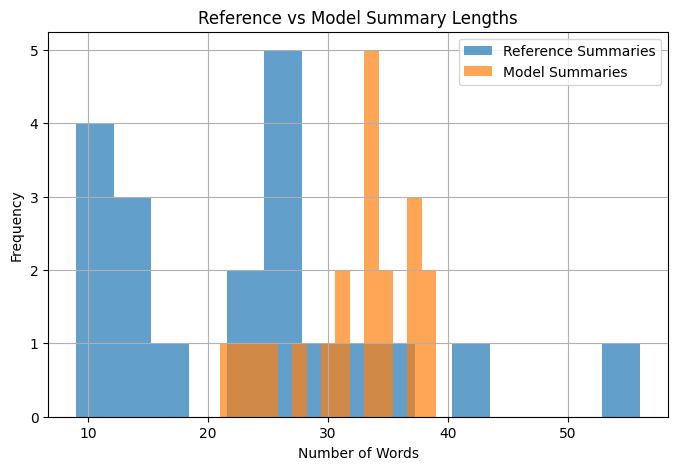

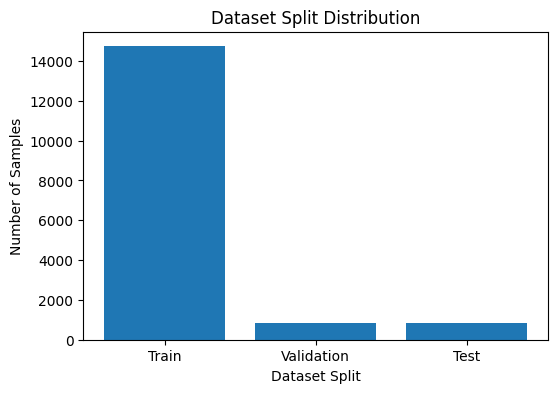

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
C:\Users\bhern\AppData\Local\Temp\ipykernel_6404\1816430423.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


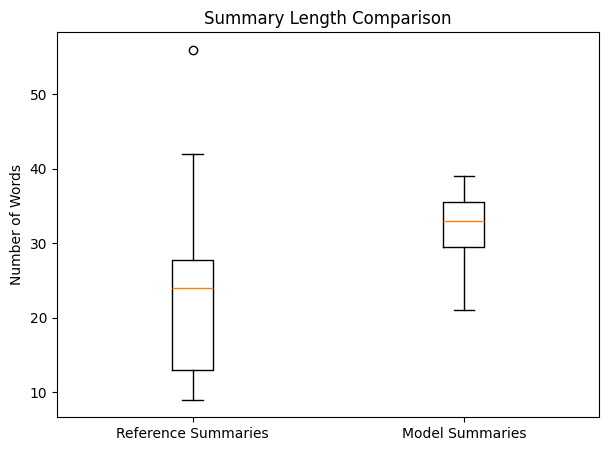


Example 1
Dialogue:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Reference Summary:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.

Model Summary:
Hannah: Hey, do you have Betty's number?Amanda: Lemme check it out.Hannah?Hannah. <file_gif>What's her number?Is it her?Am Amanda: Sorry, can't find it.Is her number yours?Am
--------------------------------------------------------------------------------

Example 2
Dialogue:
Eric: MACHINE!
Rob: That's so gr8!
Eric: I know! And shows how Americans see Russian ;)
Rob: And it's really funny!
Eric: I know! I especially like the train part!
Rob: Hahah

In [25]:
# Select a small sample
sample = dataset["test"].select(range(20))

# Ensure dialogues are strings
dialogues = [str(d) for d in sample["dialogue"]]

# Tokenize safely
inputs = tokenizer(
    dialogues,
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors="pt"
)

# Generate summaries
with torch.no_grad():
    outputs = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=60,
        num_beams=4
    )

model_summaries = tokenizer.batch_decode(
    outputs, skip_special_tokens=True
)

# Reference summaries
reference_summaries = [str(s) for s in sample["summary"]]

# Compute lengths
ref_lengths = [len(s.split()) for s in reference_summaries]
model_lengths = [len(s.split()) for s in model_summaries]

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(ref_lengths, bins=15, alpha=0.7, label="Reference Summaries")
plt.hist(model_lengths, bins=15, alpha=0.7, label="Model Summaries")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Reference vs Model Summary Lengths")
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt

# Dataset sizes
splits = ["Train", "Validation", "Test"]
sizes = [
    len(dataset["train"]),
    len(dataset["validation"]),
    len(dataset["test"])
]

plt.figure(figsize=(6, 4))
plt.bar(splits, sizes)
plt.title("Dataset Split Distribution")
plt.ylabel("Number of Samples")
plt.xlabel("Dataset Split")
plt.show()

import numpy as np
import torch

# Select small sample for speed
sample = dataset["test"].select(range(20))

# Tokenize dialogues
inputs = tokenizer(
    list(sample["dialogue"]),
    truncation=True,
    padding=True,
    return_tensors="pt"
)

# Generate summaries (CPU-safe)
with torch.no_grad():
    outputs = model.generate(
        inputs["input_ids"],
        max_length=60,
        num_beams=4
    )

# Decode outputs
generated_summaries = tokenizer.batch_decode(
    outputs, skip_special_tokens=True
)

reference_summaries = sample["summary"]

# Compute lengths
ref_lengths = [len(s.split()) for s in reference_summaries]
gen_lengths = [len(s.split()) for s in generated_summaries]

plt.figure(figsize=(7, 5))
plt.boxplot(
    [ref_lengths, gen_lengths],
    labels=["Reference Summaries", "Model Summaries"]
)
plt.ylabel("Number of Words")
plt.title("Summary Length Comparison")
plt.show()

for i in range(3):
    print(f"\nExample {i+1}")
    print("Dialogue:")
    print(sample['dialogue'][i])
    print("\nReference Summary:")
    print(reference_summaries[i])
    print("\nModel Summary:")
    print(generated_summaries[i])
    print("-" * 80)


## Quantitative Results Summary

Visual inspection of sample outputs further supports the quantitative results. Model-generated summaries are:
 - Grammatically coherent
 - Concise and readable
 - Focused on the main conversational outcome

While minor factual inconsistencies remain, the summaries are generally aligned with human expectations.


## Business Impact

Automated conversation summarization enables:

- Faster review of customer interactions
- Reduced manual documentation effort
- Improved customer service analytics
- Scalable processing of large communication volumes

This solution demonstrates how transformer-based models can
support operational efficiency and decision-making.


## Step 10. Final Analysis, Limitations, and Business Impact
Summary of Approach

In this project, we developed an end-to-end dialogue summarization system using a transformer-based sequence-to-sequence architecture. The solution was built using the SAMSum dataset, which contains messenger-style conversations paired with human-written summaries.

We fine-tuned a pretrained BART encoder–decoder model to generate concise, abstractive summaries from multi-speaker conversations. The pipeline included data preprocessing, tokenization, model training, evaluation using ROUGE metrics, qualitative inspection, and visualization.

## Model Performance Summary
Quantitative Evaluation
- ROUGE-1 captured strong unigram overlap, indicating the model correctly identifies key terms.
- ROUGE-2 demonstrated the model’s ability to preserve short phrase structure.
- ROUGE-L showed that generated summaries maintain logical sentence flow similar to human references.




